# TP 2 - Préparation de la base RAG


---
## 0. Configuration partagée


Cahier de préparation des données. La qualité de la chaîne RAG dépend directement du découpage des documents. Ici, on construit une version de base (V1) qui servira de point de comparaison.

In [1]:
from shared.config import ROOT_DIR
from shared.rag_utils import (
    rag_load_markdown_documents,
    rag_chunk_documents_by_chars,
    rag_describe_chunks,
    rag_build_chunk_embeddings,
    rag_index_chunks_chroma,
)

DATA_DIR = ROOT_DIR / "TP2_travel_planner_RAG" / "data"
MARKDOWN_DIR = DATA_DIR / "guides_markdown"
CHROMA_DIR_V1 = DATA_DIR / "chroma_db_rag_v1"

---
## 1. Charger les documents


**TODO — `rag_load_markdown_documents`**

Fichier à modifier : `shared/rag_utils.py`

La base RAG se construit à partir de documents Markdown. Cette étape sert à charger une liste de documents homogène pour la suite du TP

`rag_load_markdown_documents` : fonction qui lit les fichiers Markdown d'un dossier et retourne une liste de `MarkdownDocument` avec `source` et `text`


In [2]:
# TODO : charger les fichiers markdown et décrire la donnée
documents = rag_load_markdown_documents(MARKDOWN_DIR)

total_documents = len(documents)
total_characters = sum(len(doc["text"]) for doc in documents)

print(f"Documents Markdown chargés : {total_documents}")
print(f"Nombre total de caractères : {total_characters}")

Documents Markdown chargés : 6
Nombre total de caractères : 520892


---
## 2. Stratégie de découpage V1


**TODO — `rag_chunk_documents_by_chars`**

Fichier à modifier : `shared/rag_utils.py`

Un document complet est trop long pour la recherche. On le découpe en morceaux de taille comparable, mesurés en nombre de caractères
L'overlap garde une zone de texte partagée entre deux chunks voisins pour conserver la continuité

`rag_chunk_documents_by_chars` : fonction qui découpe chaque `MarkdownDocument` en `RAGChunk` avec une fenêtre glissante de taille fixe et overlap, en redémarrant `chunk_id` à 0 pour chaque document

Paramètres déjà définis : `CHUNK_CHARS_V1`, `CHUNK_OVERLAP_V1`
Repère attendu : entre 100 et 500 chunks au total sur l'ensemble des documents

Après exécution, vérifie la distribution des tailles de chunks dans la cellule d'inspection

Cette V1 est la référence de comparaison avant la V2 orientée structure dans le notebook `2_3`


In [3]:
# TODO : découper chaque document avec fenêtre glissante + overlap

chunks_v1 = rag_chunk_documents_by_chars(
    documents=documents,
    chunk_chars=1200,
    chunk_overlap_chars=200,
)

Découpage des documents: 100%|██████████| 6/6 [00:00<00:00, 8402.61doc/s]


### Inspection: chunks V1 (`rag_describe_chunks`)

`rag_describe_chunks` est une fonction de contrôle : statistiques + visualisations.
Elle permet de vérifier immédiatement si les chunks sont de bonne taille et bien repartis parmi les documents.

Exemple de statistiques à afficher :
![image.png](attachment:48e6013a-a876-45b3-86f7-0db15873d766.png)

count: 524
min length: 8
median length: 1200
max length: 1200
mean length: 1191


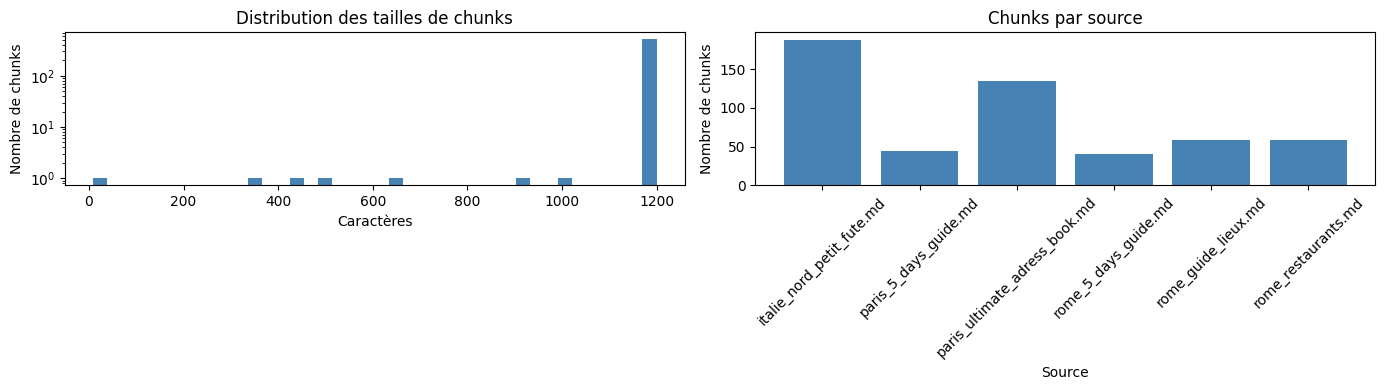

In [4]:
rag_describe_chunks(chunks_v1)

**TODO** : Afficher quelques chunks pour comprendre le résultat du découpage.

In [5]:
for chunk in [chunk.text for chunk in chunks_v1[::100]]:
    print(f"Exemple de chunk : {chunk}\n------------------------------")

Exemple de chunk : # Italie du Nord — Petit Futé

## EDITION 

**Directeurs de collection et auteurs** : Dominique AUZIAS et Jean-Paul LABOURDETTE **Auteurs** : Marie-Isabelle CORRADI, Abdesslam BENZITOUNI, Laetitia DUPONT, Fédérica VISANI, Maxence GORREGUES, Sophie FRECHON, Thomas SAINTOURENS, Charlotte PAVARD, Milly NEAU, Jean-Paul LABOURDETTE, Dominique AUZIAS et alter **Directeur Editorial** : Stéphan SZEREMETA **Responsable Editorial Monde** : Patrick MARINGE **Rédaction Monde** : Caroline MICHELOT, Morgane VESLIN, Julien BERNARD et Pierre-Yves SOUCHET **Rédaction France** : François TOURNIE, Jeff BUCHE, Grégoire DECONIHOUT et Perrine GALAZKA FABRICATION **Responsable Studio** : Sophie LECHERTIER assistée de Romain AUDREN **Maquette et Montage** : Julie BORDES, Élodie CLAVIER, Sandrine MECKING, Delphine PAGANO et Laurie PILLOIS **Iconographie et Cartographie** : Robin BEDDAR 

WEB ET NUMERIQUE **Directeur technique** : Lionel CAZAUMAYOU **Chef de projet et développeurs** : Jean-Ma

---
## 3. Vectorisation et indexation


**TODO — `rag_build_chunk_embeddings` et `rag_index_chunks_chroma`**

Fichier à modifier : `shared/rag_utils.py`

Après le découpage, chaque chunk doit être transformé en vecteur pour pouvoir être recherché dans Chroma

`rag_embed_texts` : fonction pour calculer les embeddings d'une liste de textes (un batch de textes)

`rag_build_chunk_embeddings` : fonction qui calcule les embeddings de tous les `RAGChunk`

`rag_index_chunks_chroma` : fonction qui reconstruit la base Chroma V1 en stockant textes, ids, embeddings et métadonnées (`source`, `chunk_id`)


### V1 — Vectorisation et indexation

In [7]:
# TODO : vectoriser les chunks en batch sans casser l'alignement chunk-vecteur
# Paramètres de throttling pour l'API Google (limite: 60 req/min par défaut)
chunk_embeddings_v1 = rag_build_chunk_embeddings(
    chunks=chunks_v1,
    batch_size=16,
    requests_per_minute=5,  
    max_retries=3,           # Nombre de tentatives en cas de quota exceeded
)

INFO:shared.rag_utils:🚀 Début du calcul d'embeddings pour 524 chunks
INFO:shared.rag_utils:⚙️ Paramètres: batch_size=16, requests_per_minute=5, max_retries=3
Calcul des embeddings:   0%|          | 0/33 [00:00<?, ?batch/s]INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-2-preview:batchEmbedContents "HTTP/1.1 200 OK"
INFO:shared.rag_utils:Embeddings calculés avec succès pour 16 textes
Calcul des embeddings:   3%|▎         | 1/33 [00:13<07:09, 13.42s/batch]INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-2-preview:batchEmbedContents "HTTP/1.1 200 OK"
INFO:shared.rag_utils:Embeddings calculés avec succès pour 16 textes
Calcul des embeddings:   6%|▌         | 2/33 [00:26<06:53, 13.33s/batch]INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-2-preview:batchEmbedContents "HTTP/1.1 200 OK"
INFO:shared.rag_utils:Embeddings calculés avec

In [8]:
# TODO : indexer dans Chroma avec ids + metadata traçables
rag_index_chunks_chroma(
    persist_dir=CHROMA_DIR_V1,
    chunks=chunk_embeddings_v1,
)

print(f"V1 — Chunks indexés : {len(chunk_embeddings_v1)}")
print(f"V1 — Dimension des embeddings : {len(chunk_embeddings_v1[0].embedding) if chunk_embeddings_v1 else 0}")


INFO:chromadb.telemetry.product.posthog:Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.


V1 — Chunks indexés : 524
V1 — Dimension des embeddings : 3072
